# 03 — Indicators Visualization

Visual verification that all Week 2 indicators compute correctly on real BTCUSDT 1D data.

**Indicators:** SMA · EMA · Bollinger Bands · RSI · MACD · ATR · OBV · Drawdown from ATH · Swing Highs/Lows

In [1]:
# Cell 1 — Setup
import sys
from pathlib import Path

project_root = Path.cwd().parent
if str(project_root / "src") not in sys.path:
    sys.path.insert(0, str(project_root / "src"))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
matplotlib.rcParams.update({"figure.dpi": 110, "axes.titlesize": 11, "axes.labelsize": 9})

from btc_quant.data.storage import ParquetStorage
from btc_quant.indicators.trend import sma, ema, macd
from btc_quant.indicators.oscillators import rsi
from btc_quant.indicators.volatility import atr, bollinger_bands
from btc_quant.indicators.volume import obv
from btc_quant.indicators.structure import drawdown_from_ath, swing_highs_lows

BASE_PATH = str(project_root / "data" / "processed")
storage = ParquetStorage()
df = storage.load("BTCUSDT", "1d", BASE_PATH)
# Work on real candles only for cleaner indicator output
df = df[~df["is_synthetic"]].reset_index(drop=True)

close  = df["close"]
high   = df["high"]
low    = df["low"]
volume = df["volume"]
ts     = df["timestamp_utc"]

print(f"Loaded {len(df):,} real candles: {ts.iloc[0].date()} → {ts.iloc[-1].date()}")

2026-05-08 00:37:28.843 | INFO     | btc_quant.data.storage:load:123 - Loaded 3185 rows ← /Users/roger/Desktop/btc-quant/data/processed/btcusdt_1d.parquet


Loaded 3,185 real candles: 2017-08-17 → 2026-05-06


In [2]:
# Cell 2 — Compute all indicators
SMA50  = sma(close, 50)
SMA200 = sma(close, 200)
BB     = bollinger_bands(close, period=20, num_std=2.0)
RSI14  = rsi(close, period=14)
MACD_  = macd(close, fast_period=12, slow_period=26, signal_period=9)
ATR14  = atr(high, low, close, period=14, method="wilders")
OBV_   = obv(close, volume)
DD     = drawdown_from_ath(close)
SWINGS = swing_highs_lows(high, low, lookback=5)

print("All indicators computed successfully.")
print(f"  SMA50  non-NaN: {SMA50.notna().sum():,}")
print(f"  SMA200 non-NaN: {SMA200.notna().sum():,}")
print(f"  RSI14  non-NaN: {RSI14.notna().sum():,}")
print(f"  ATR14  non-NaN: {ATR14.notna().sum():,}")
print(f"  Swing highs:    {SWINGS['is_swing_high'].sum():,}")
print(f"  Swing lows:     {SWINGS['is_swing_low'].sum():,}")

All indicators computed successfully.
  SMA50  non-NaN: 3,136
  SMA200 non-NaN: 2,986
  RSI14  non-NaN: 3,171
  ATR14  non-NaN: 3,172
  Swing highs:    186
  Swing lows:     207


/var/folders/f0/_yxt9pn568g64wjpqlmhd8780000gn/T/ipykernel_40249/1566379086.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


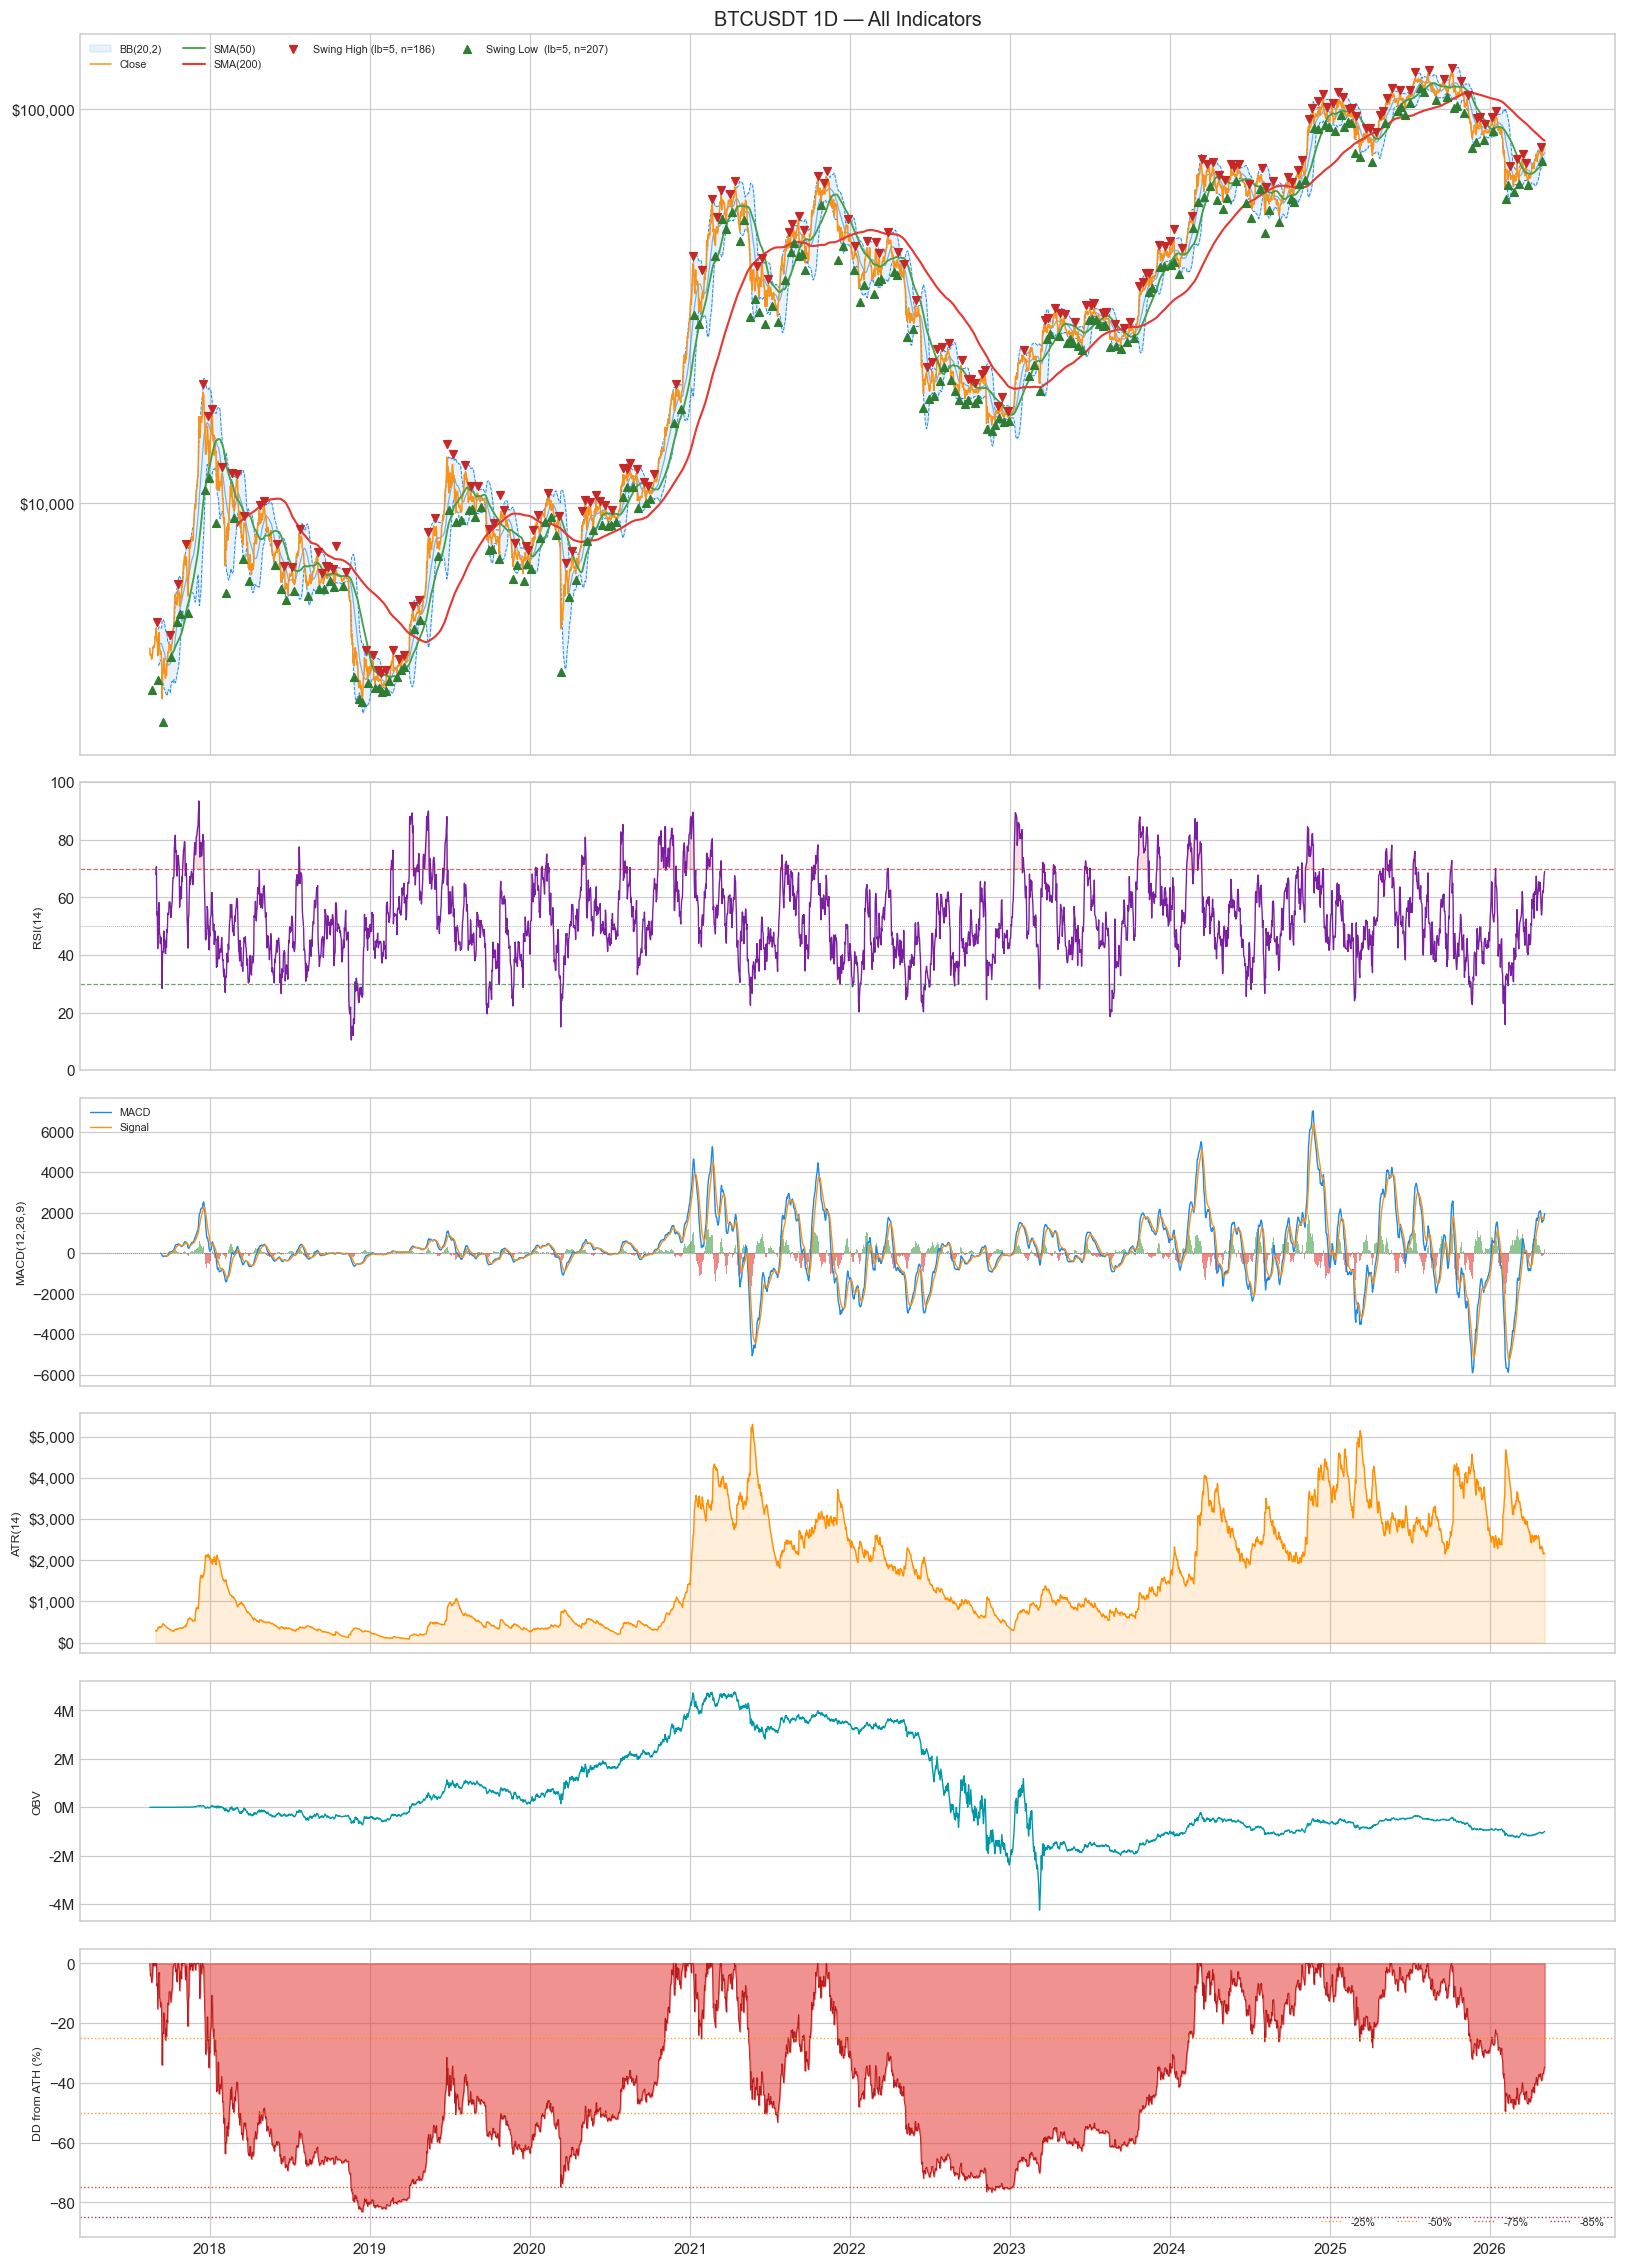

In [3]:
# Cell 3 — Multi-panel chart
USD_FMT = mticker.FuncFormatter(lambda x, _: f"${x:,.0f}")
YEAR_LOC = mdates.YearLocator()
YEAR_FMT = mdates.DateFormatter("%Y")

fig = plt.figure(figsize=(18, 26))
gs = gridspec.GridSpec(
    6, 1, figure=fig,
    height_ratios=[3, 1.2, 1.2, 1, 1, 1.2],
    hspace=0.08,
)

ax_p   = fig.add_subplot(gs[0])
ax_rsi = fig.add_subplot(gs[1], sharex=ax_p)
ax_mac = fig.add_subplot(gs[2], sharex=ax_p)
ax_atr = fig.add_subplot(gs[3], sharex=ax_p)
ax_obv = fig.add_subplot(gs[4], sharex=ax_p)
ax_dd  = fig.add_subplot(gs[5], sharex=ax_p)

# ── Panel 1: Price + SMA + BB + Swings ──────────────────────────────────────
ax_p.fill_between(ts, BB["lower"], BB["upper"], alpha=0.10, color="#1E88E5", label="BB(20,2)")
ax_p.plot(ts, BB["upper"],  lw=0.6, color="#1E88E5", linestyle="--")
ax_p.plot(ts, BB["lower"],  lw=0.6, color="#1E88E5", linestyle="--")
ax_p.plot(ts, BB["middle"], lw=0.8, color="#1E88E5", alpha=0.6)
ax_p.plot(ts, close,   lw=1.0, color="#F7931A", label="Close")
ax_p.plot(ts, SMA50,   lw=1.2, color="#43A047", label="SMA(50)")
ax_p.plot(ts, SMA200,  lw=1.4, color="#E53935", label="SMA(200)")

# Swing markers
sh_mask = SWINGS["is_swing_high"]
sl_mask = SWINGS["is_swing_low"]
if sh_mask.any():
    ax_p.scatter(ts[sh_mask], high[sh_mask] * 1.012,
                 marker="v", color="#C62828", s=25, zorder=5,
                 label=f"Swing High (lb=5, n={sh_mask.sum()})")
if sl_mask.any():
    ax_p.scatter(ts[sl_mask], low[sl_mask] * 0.988,
                 marker="^", color="#2E7D32", s=25, zorder=5,
                 label=f"Swing Low  (lb=5, n={sl_mask.sum()})")

ax_p.set_yscale("log")
ax_p.yaxis.set_major_formatter(USD_FMT)
ax_p.set_title("BTCUSDT 1D — All Indicators", fontsize=13, pad=6)
ax_p.legend(loc="upper left", fontsize=7, ncol=4)

# ── Panel 2: RSI ─────────────────────────────────────────────────────────────
ax_rsi.plot(ts, RSI14, lw=0.9, color="#7B1FA2")
ax_rsi.axhline(70, color="#C62828", lw=0.8, linestyle="--", alpha=0.7)
ax_rsi.axhline(30, color="#2E7D32", lw=0.8, linestyle="--", alpha=0.7)
ax_rsi.axhline(50, color="gray",    lw=0.5, linestyle=":")
ax_rsi.fill_between(ts, RSI14, 70, where=(RSI14 >= 70), alpha=0.15, color="#C62828")
ax_rsi.fill_between(ts, RSI14, 30, where=(RSI14 <= 30), alpha=0.15, color="#2E7D32")
ax_rsi.set_ylim(0, 100)
ax_rsi.set_ylabel("RSI(14)", fontsize=8)

# ── Panel 3: MACD ─────────────────────────────────────────────────────────────
ml = MACD_["macd_line"]
sl = MACD_["signal_line"]
hist = MACD_["histogram"]
colors_hist = np.where(hist >= 0, "#43A047", "#E53935")
ax_mac.bar(ts, hist, width=1.0, color=colors_hist, alpha=0.6)
ax_mac.plot(ts, ml, lw=0.9, color="#1E88E5", label="MACD")
ax_mac.plot(ts, sl, lw=0.9, color="#F7931A", label="Signal")
ax_mac.axhline(0, color="gray", lw=0.5, linestyle=":")
ax_mac.set_ylabel("MACD(12,26,9)", fontsize=8)
ax_mac.legend(loc="upper left", fontsize=7)

# ── Panel 4: ATR ──────────────────────────────────────────────────────────────
ax_atr.plot(ts, ATR14, lw=0.9, color="#FF8F00")
ax_atr.fill_between(ts, ATR14, alpha=0.15, color="#FF8F00")
ax_atr.set_ylabel("ATR(14)", fontsize=8)
ax_atr.yaxis.set_major_formatter(USD_FMT)

# ── Panel 5: OBV ──────────────────────────────────────────────────────────────
ax_obv.plot(ts, OBV_, lw=0.9, color="#0097A7")
ax_obv.set_ylabel("OBV", fontsize=8)
ax_obv.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x/1e6:.0f}M")
)

# ── Panel 6: Drawdown from ATH ────────────────────────────────────────────────
ax_dd.fill_between(ts, DD["drawdown"] * 100, 0, alpha=0.55, color="#E53935")
ax_dd.plot(ts, DD["drawdown"] * 100, lw=0.6, color="#B71C1C")
for level, col in [(-25, "#FF8F00"), (-50, "#F57F17"), (-75, "#BF360C"), (-85, "#880E4F")]:
    ax_dd.axhline(level, color=col, lw=0.9, linestyle=":", alpha=0.85, label=f"{level}%")
ax_dd.set_ylabel("DD from ATH (%)", fontsize=8)
ax_dd.set_ylim(DD["drawdown"].min() * 110, 5)
ax_dd.legend(loc="lower right", fontsize=7, ncol=4)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
for ax in [ax_p, ax_rsi, ax_mac, ax_atr, ax_obv]:
    plt.setp(ax.get_xticklabels(), visible=False)
ax_dd.xaxis.set_major_locator(YEAR_LOC)
ax_dd.xaxis.set_major_formatter(YEAR_FMT)

fig.tight_layout()
plt.show()

## Nota sobre Swing Highs/Lows y Look-Ahead

> **Los markers se muestran en su posición final (barra t).** En operación real, cada swing solo se conocería `lookback` velas después de ocurrir.
>
> Con `lookback=5`, un swing high en la barra `t` solo sería accionable en la barra `t+5`. Operar en `t` directamente introduce **look-ahead bias**: el backtest usaría información del futuro y los resultados serían irrealistamente optimistas.
>
> **Uso correcto en backtest:**
> ```python
> is_swing_high = swing_highs_lows(high, low, lookback=5)["is_swing_high"]
> for t in range(n):
>     if t >= lookback and is_swing_high.iloc[t - lookback]:
>         # El swing ocurrió en t-lookback, ahora sí podemos actuar
>         ...
> ```